# Exercise 3

## Imports

In [114]:
import os
from pathlib import Path
from typing import List

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydub import AudioSegment
from scipy import stats
from scipy.io import arff

## Constants

In [115]:
current_dir = Path.cwd()

# Music file
classical_audiofile_path = current_dir.joinpath("data", "classical.mp3")

# Features
features_folder_path = current_dir.joinpath("data", "features")

# Audio chunks output
audio_chunks_output_path = current_dir.joinpath("data", "outputs", "audio_chunks")

## Exercise 1

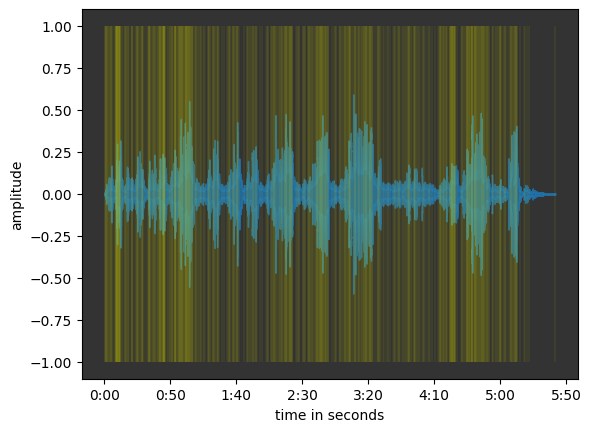

In [116]:
y, sr = librosa.load(classical_audiofile_path)
duration_sec = len(y) / sr
duration_ms = duration_sec * 1000

onsets = librosa.onset.onset_detect(y=y, sr=sr)
onset_times = librosa.frames_to_time(onsets, sr=sr)

# plot everything
plt.figure()
ax = plt.subplot(1, 1, 1)
ax.set_facecolor("#333333")

librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.8)

ax.vlines(onset_times, -1, 1, linestyle="-", alpha=0.05, color="yellow")
ax.set_xlabel("time in seconds")
ax.set_ylabel("amplitude")

plt.show()

## Exercise 2

In [117]:
# SPLIT AUDIO INTO 5s CHUNKS
audio = AudioSegment.from_mp3(classical_audiofile_path)

chunk_seconds = 5
chunk_length_ms = chunk_seconds * 1000

chunk_paths = []
chunk_onsets = []
for i in range(0, len(audio), chunk_length_ms):
    chunk_id = i // chunk_length_ms
    chunk = audio[i:i + chunk_length_ms]
    chunk_file_name = f"chunk_{chunk_id}.mp3"
    chunk_path = audio_chunks_output_path.joinpath(chunk_file_name)

    chunk.export(chunk_path, format="mp3")
    chunk_paths.append(chunk_path)

    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)

    # For ex2
    chunk_onsets.append(len(onsets))
    print(f"chunk {chunk_id} -> nº onsets = {len(onsets)}")

chunk 0 -> nº onsets = 13
chunk 1 -> nº onsets = 19
chunk 2 -> nº onsets = 28
chunk 3 -> nº onsets = 10
chunk 4 -> nº onsets = 12
chunk 5 -> nº onsets = 15
chunk 6 -> nº onsets = 11
chunk 7 -> nº onsets = 15
chunk 8 -> nº onsets = 19
chunk 9 -> nº onsets = 21
chunk 10 -> nº onsets = 19
chunk 11 -> nº onsets = 21
chunk 12 -> nº onsets = 25
chunk 13 -> nº onsets = 14
chunk 14 -> nº onsets = 13
chunk 15 -> nº onsets = 14
chunk 16 -> nº onsets = 16
chunk 17 -> nº onsets = 13
chunk 18 -> nº onsets = 15
chunk 19 -> nº onsets = 13
chunk 20 -> nº onsets = 13
chunk 21 -> nº onsets = 14
chunk 22 -> nº onsets = 17
chunk 23 -> nº onsets = 18
chunk 24 -> nº onsets = 17
chunk 25 -> nº onsets = 15
chunk 26 -> nº onsets = 19
chunk 27 -> nº onsets = 18
chunk 28 -> nº onsets = 18
chunk 29 -> nº onsets = 14
chunk 30 -> nº onsets = 14
chunk 31 -> nº onsets = 20
chunk 32 -> nº onsets = 22
chunk 33 -> nº onsets = 18
chunk 34 -> nº onsets = 18
chunk 35 -> nº onsets = 13
chunk 36 -> nº onsets = 19
chunk 37 ->

In [118]:
# READ FEATURES AND MERGE THEM BY CHUNKS
arff_files = sorted(
    [os.path.join(features_folder_path, f) for f in os.listdir(features_folder_path) if f.endswith(".arff")])

# Read features into df
dfs = []
for f in arff_files:
    data, meta = arff.loadarff(f)
    df = pd.DataFrame(data)
    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.set_index('WindowNumber', inplace=True)
    dfs.append(df)
features_df = pd.concat(dfs, axis=1)
print(features_df)

/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_8978/1244638929.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0                 0.025391          1828.1770 

In [119]:
num_windows = features_df.shape[0]
print(f"Number of feature windows: {num_windows}")
print(f"Duration of piece (ms): {duration_ms:.2f}")

# Calculate exact windows per chunk based on actual number of chunks
num_chunks = len(chunk_paths)
windows_per_chunk = num_windows // num_chunks  # This gives you 213 windows/chunk
remainder_windows = num_windows % num_chunks
print(f"Windows per chunk: {windows_per_chunk}")
print(f"Remainder windows: {remainder_windows}")

# Better grouping that handles the remainder
chunk_ids = np.repeat(range(num_chunks), windows_per_chunk)
# Assign remaining windows to last chunk
chunk_ids = np.append(chunk_ids, [num_chunks - 1] * remainder_windows)
features_df['chunk_id'] = chunk_ids
print(features_df)

avg_features_per_chunk_df = (features_df
                             .groupby('chunk_id')
                             .mean(numeric_only=True))
print(avg_features_per_chunk_df)

Number of feature windows: 14720
Duration of piece (ms): 341812.24
Windows per chunk: 213
Remainder windows: 23
              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0            

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


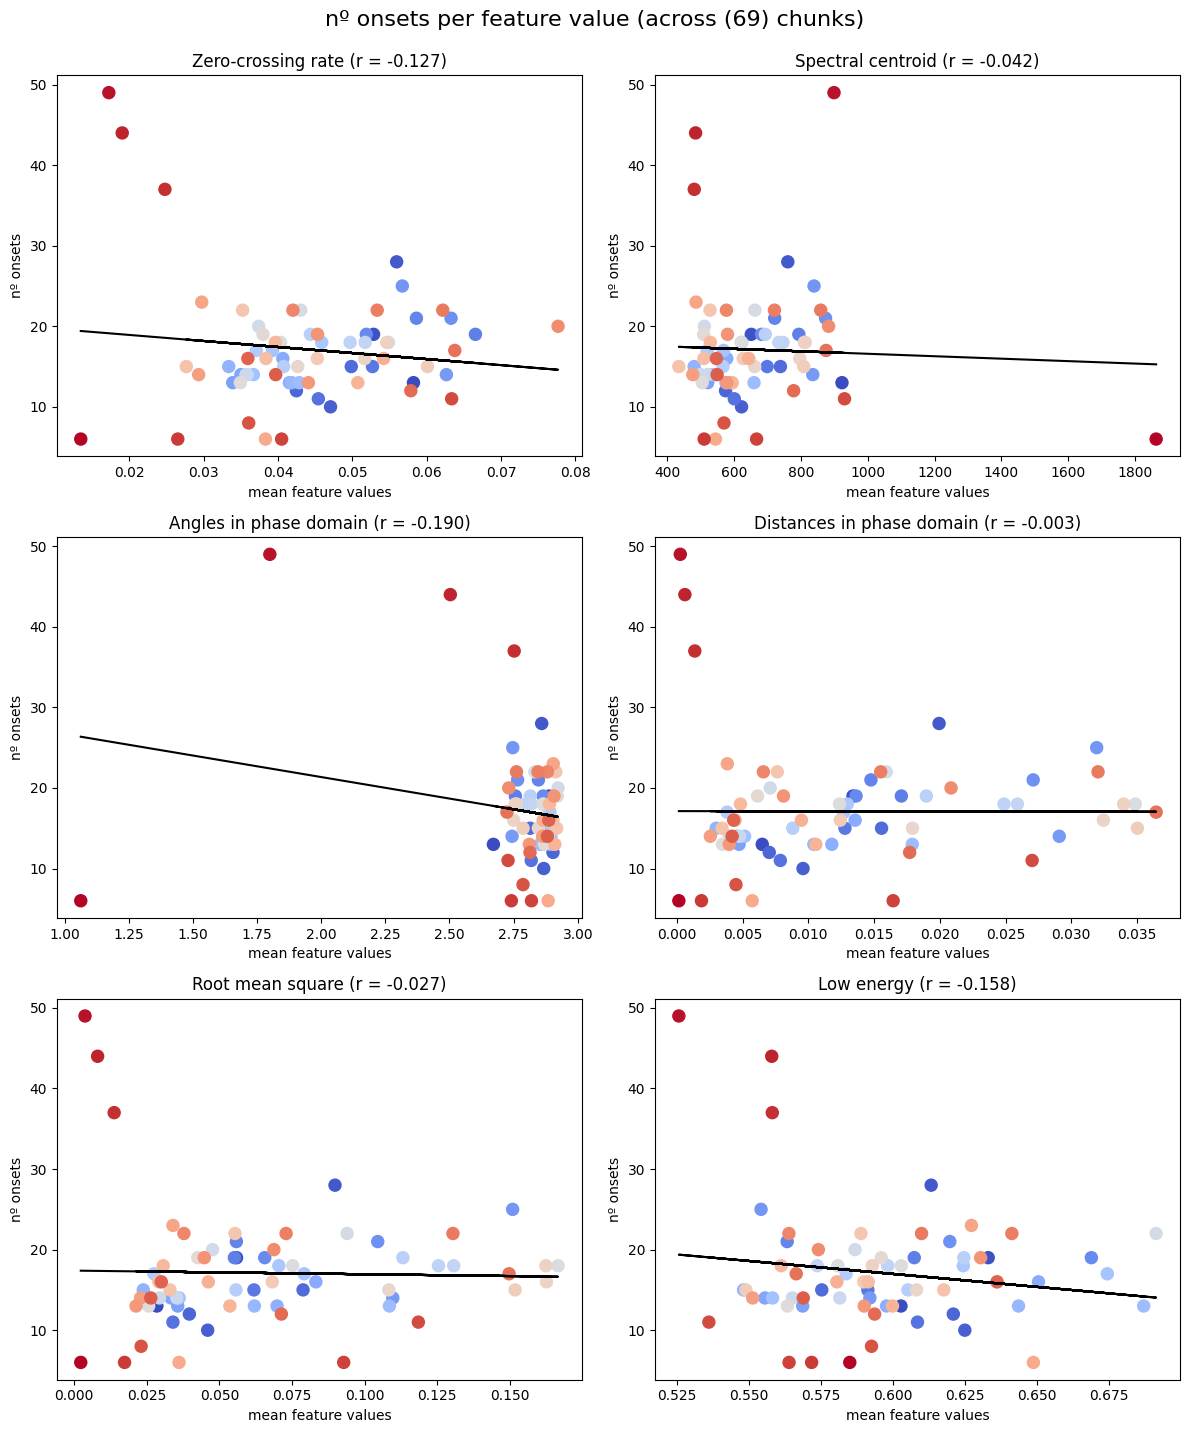

In [129]:
# PLOT [nº ONSETS X avg FEATURE VALUE]

def plot_features(df: pd.DataFrame, title: str = "", regression_line: bool = False,
                  ignored_column_names: List[str] = ["chunk_id", "is_onset", "is_non_onset"]):
    regression_value_map = {}

    plt.figure(figsize=(12, 14))
    colors = np.arange(len(chunk_onsets))

    for f_idx, feature in enumerate(features_df.columns):
        if feature in ignored_column_names:
            continue
        print(f"Plotting for feature: {feature}")

        plt.subplot(3, 2, f_idx + 1)

        x = np.array(df[feature])
        y = np.array(chunk_onsets)
        plt.scatter(x, y, c=colors, cmap='coolwarm', marker='o', s=75)
        #plt.scatter(df[feature], chunk_onsets, c="blue", marker='o', s=75)

        # Regression Line
        if regression_line:
            slope, intercept, r, p, std_err = stats.linregress(x, y)
            plt.plot(x, slope * x + intercept, color="black", label=f"{r}")

            regression_value_map[feature] = {
                "r": r,
                "p": p,
            }
            plt.title(f"{feature} (r = {r:.3f})")
        else:
            plt.title(f"{feature}")

        plt.xlabel("mean feature values")
        plt.ylabel("nº onsets")
        plt.tight_layout()

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

    return regression_value_map


og_correlations = plot_features(avg_features_per_chunk_df,
                                title=f"nº onsets per feature value (across ({len(chunk_onsets)}) chunks)",
                                regression_line=True)

## Exercise 3

In [130]:
onset_frames_mask = np.zeros(num_windows, dtype=bool)
non_onset_frames_mask = np.zeros(num_windows, dtype=bool)

ms_per_window = duration_ms / num_windows
print(f"Windows (ms): {ms_per_window:.2f}")


def get_window_id(onset_time_ms: float):
    return int(onset_time_ms // ms_per_window)


prev_window_id = None
for chunk_idx, chunk_path in enumerate(chunk_paths):
    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)
    onsets_ms = librosa.frames_to_time(onsets, sr=sr) * 1000

    base_time_ms = chunk_idx * chunk_seconds * 1000
    for onset_ms in onsets_ms:
        window_id = get_window_id(base_time_ms + onset_ms)

        # Mark Onset Frame
        onset_frames_mask[window_id] = True

        # Find middles and mark as non-onset
        if prev_window_id is not None:
            middle_window_id = prev_window_id + ((window_id - prev_window_id) // 2)
            if not onset_frames_mask[middle_window_id]:
                non_onset_frames_mask[middle_window_id] = True

        prev_window_id = window_id

print(f"Overlap: {np.sum(onset_frames_mask & non_onset_frames_mask)}")

features_df['is_onset'] = onset_frames_mask
features_df['is_non_onset'] = non_onset_frames_mask
print(features_df)

Windows (ms): 23.22
Overlap: 0
              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0              

In [131]:
onset_frames_df = (features_df[features_df['is_onset']]
                   .groupby('chunk_id')
                   .mean(numeric_only=True)
                   .reset_index())
print(onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.069636         886.910948                2.702200   
1          1            0.064967         748.896864                2.882550   
2          2            0.060041         814.350376                2.848716   
3          3            0.053445         705.952891                2.859799   
4          4            0.047585         625.059975                2.903889   
..       ...                 ...                ...                     ...   
64        64            0.033984         534.332220                2.848291   
65        65            0.027794         480.763196                2.789508   
66        66            0.018973         486.392329                2.487159   
67        67            0.017483         929.171589                1.823978   
68        68            0.010076        1781.071354                1.067810   

    Distances in phase domain  Root mean square  Lo

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


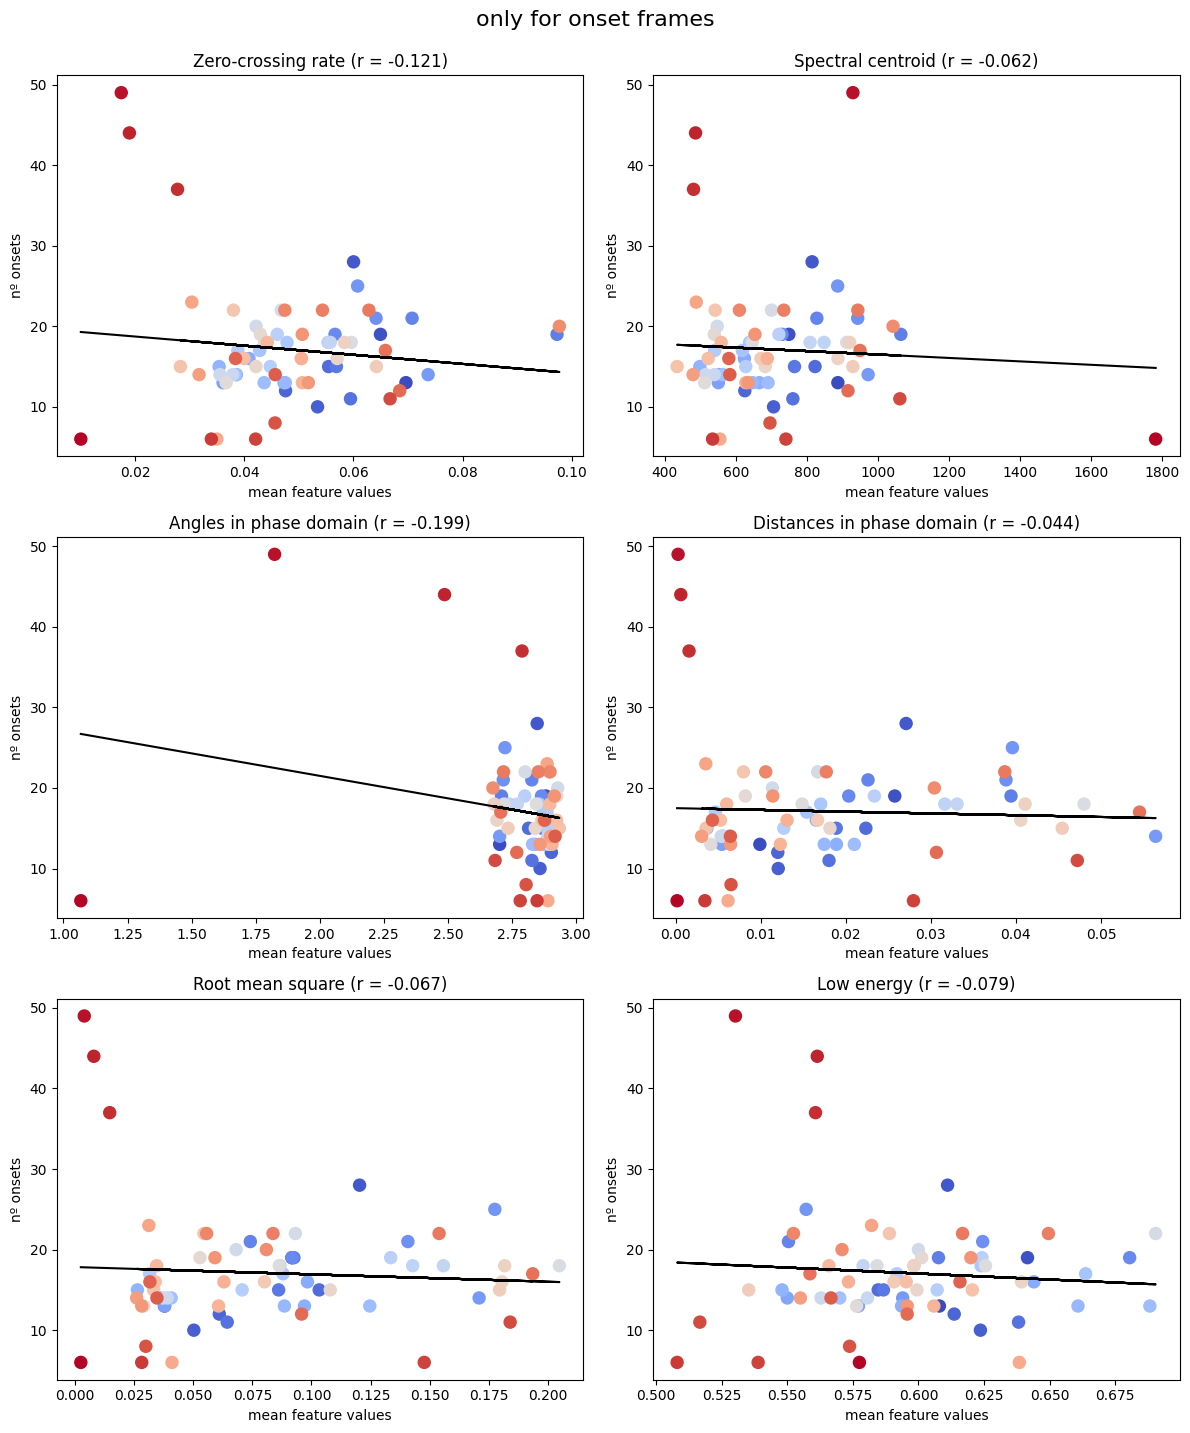

In [132]:
onset_correlations = plot_features(onset_frames_df,
                                   title="only for onset frames",
                                   regression_line=True)

In [133]:
onset_frames_df = (features_df[features_df['is_non_onset']]
                   .groupby('chunk_id')
                   .mean(numeric_only=True)
                   .reset_index())
print(onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.060096         980.443276                2.710772   
1          1            0.059787         693.624253                2.879938   
2          2            0.058803         784.963167                2.851578   
3          3            0.041016         607.351407                2.864820   
4          4            0.044434         589.177149                2.916671   
..       ...                 ...                ...                     ...   
64        64            0.028971         494.387267                2.812697   
65        65            0.024790         466.501016                2.756289   
66        66            0.018436         488.210055                2.506226   
67        67            0.018769         904.547674                1.839186   
68        68            0.013894        1842.388607                1.058374   

    Distances in phase domain  Root mean square  Lo

Plotting for feature: Zero-crossing rate
Plotting for feature: Spectral centroid
Plotting for feature: Angles in phase domain
Plotting for feature: Distances in phase domain
Plotting for feature: Root mean square
Plotting for feature: Low energy


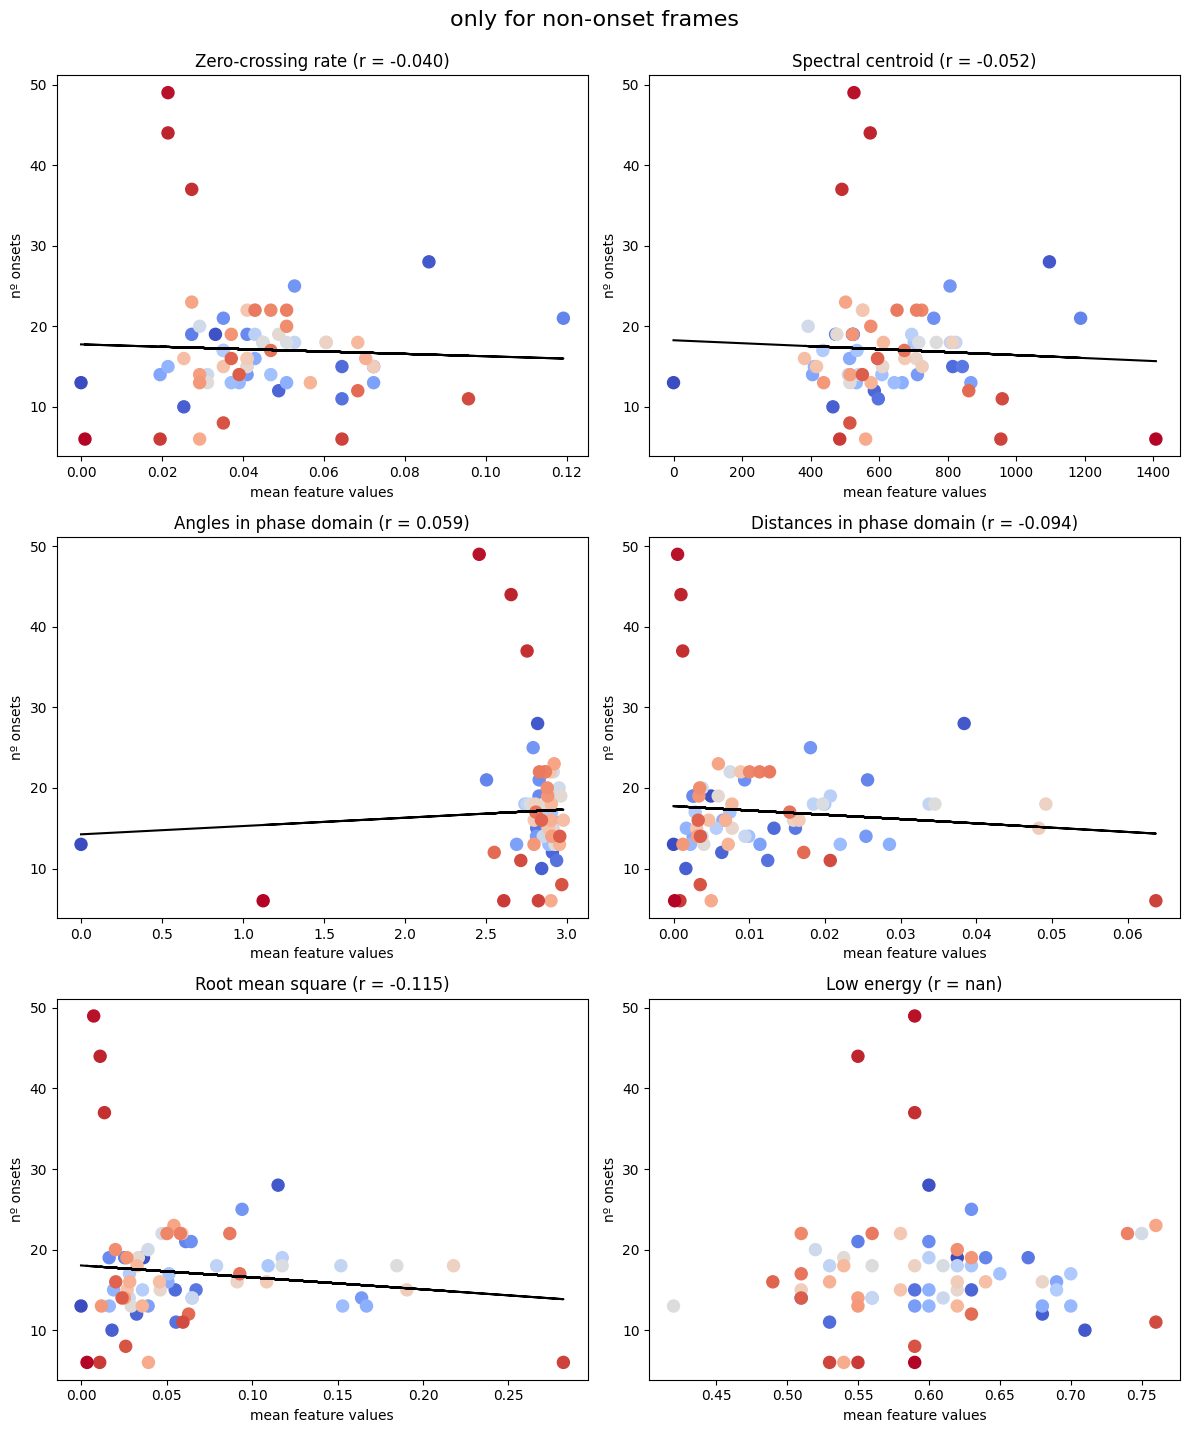

In [134]:
non_onset_correlations = plot_features(non_onset_frames_df, title="only for non-onset frames", regression_line=True)

# Extra: comparing correlations

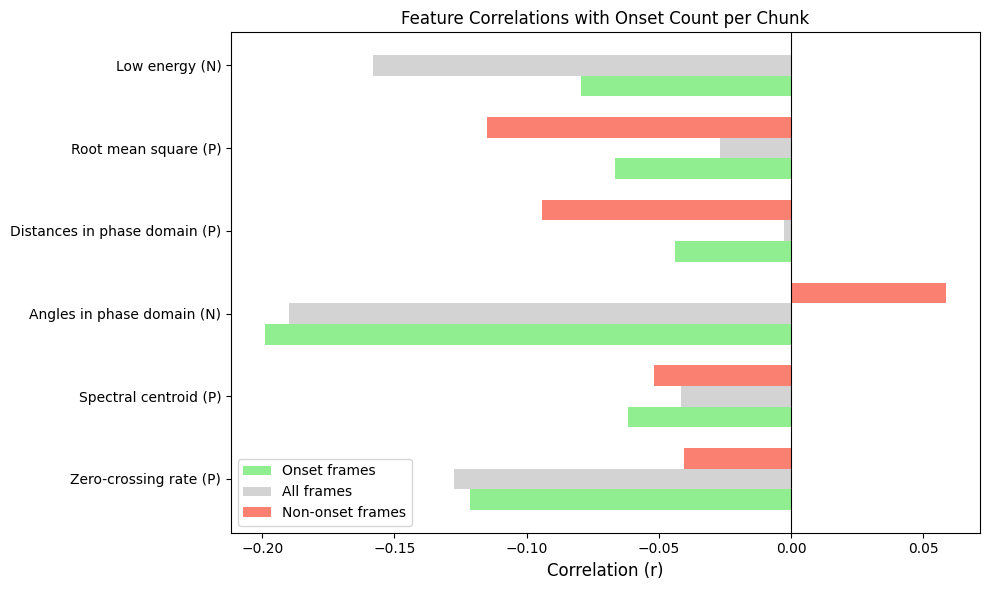

In [147]:
expected_correlation = {
    "Zero-crossing rate": True,
    "Spectral centroid": True,
    "Angles in phase domain": False,
    "Distances in phase domain": True,
    "Root mean square": True,
    "Low energy": False,
}


def plot_correlation_comparison(regression_maps, title="Feature Correlations with Onset Count per Chunk"):
    """
    regression_maps: dict with keys like 'all_frames', 'onset_frames', 'non_onset_frames'
                     each containing {feature_name: {'r': value, 'p': value}}
    """
    features = list(next(iter(regression_maps.values())).keys())

    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(features))
    width = 0.25

    colors = ['lightgreen', 'lightgrey', 'salmon']

    for i, (label, data) in enumerate(regression_maps.items()):
        r_values = [data[f]['r'] if f in data else 0 for f in features]
        p_values = [data[f]['p'] if f in data else 1 for f in features]

        ax.barh(x + i * width, r_values, width, label=label, color=colors[i])

    mod_features = [f"{f} (P)" if expected_correlation[f] else f"{f} (N)" for f in features]

    ax.set_xlabel('Correlation (r)', fontsize=12)
    ax.set_yticks(x + width)
    ax.set_yticklabels(mod_features)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Usage:
correlation_results = {
    'Onset frames': onset_correlations,
    'All frames': og_correlations,
    'Non-onset frames': non_onset_correlations
}
plot_correlation_comparison(correlation_results)